In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import datetime as dt
import seaborn as sns
import numpy as np
from mlxtend.frequent_patterns import association_rules, apriori
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import math
import warnings
warnings.filterwarnings("ignore")

In [32]:
import platform
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic') 
else:   
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

In [33]:
df = pd.read_parquet("V2_merge.parquet")

In [ ]:
# 1. Parquet 파일 불러오기
# df = pd.read_parquet('V2_merge.parquet')

# 2. CSV 파일로 내보내기 
# (utf-8-sig는 태블로에서 한글이 깨지는 것을 방지해줍니다)
# df.to_csv("V2_merge_final.csv", index=False, encoding='utf-8-sig')

# print("변환 완료! 태블로에서 '텍스트 파일' 연결을 눌러 'V2_merge_final.csv'를 선택하세요.")

변환 완료! 태블로에서 '텍스트 파일' 연결을 눌러 'V2_merge_final.csv'를 선택하세요.


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31097423 entries, 0 to 31097422
Data columns (total 23 columns):
 #   Column                        Dtype         
---  ------                        -----         
 0   t_dat                         datetime64[us]
 1   customer_id                   int32         
 2   article_id                    int32         
 3   price                         float32       
 4   sales_channel_id              int8          
 5   FN                            int8          
 6   Active                        int8          
 7   club_member_status            category      
 8   fashion_news_frequency        str           
 9   age                           int8          
 10  age_group                     category      
 11  prod_name                     category      
 12  product_type_name             category      
 13  product_group_name            category      
 14  graphical_appearance_name     category      
 15  colour_group_name             category   

In [ ]:
df.columns

Index(['t_dat', 'customer_id', 'article_id', 'price', 'sales_channel_id', 'FN',
       'Active', 'club_member_status', 'fashion_news_frequency', 'age',
       'age_group', 'prod_name', 'product_type_name', 'product_group_name',
       'graphical_appearance_name', 'colour_group_name',
       'perceived_colour_value_name', 'perceived_colour_master_name',
       'department_name', 'index_name', 'index_group_name', 'section_name',
       'garment_group_name'],
      dtype='str')

## RFM 지표

In [ ]:
# 1. RFM 지표 계산
snapshot_date = df['t_dat'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    Recency=('t_dat', lambda x: (snapshot_date - x.max()).days),
    Frequency=('t_dat', 'nunique'),
    Monetary=('price', 'sum')
).reset_index()

# 2. 확인
print(rfm.head())

   customer_id  Recency  Frequency     Monetary
0            0       18         10   382.899994
1            1       77         23  1535.140015
2            2        8          7   415.820007
3            3      472          1    35.980000
4            4       42          6   277.119995


#### 4분위수로 확인

In [ ]:
quantiles = [0.25, 0.5, 0.75]

# 1. 각 지표별 경계값(Quantile) 계산
# .quantile() 함수를 사용하면 해당 백분율에 위치한 실제 값을 바로 찾아줍니다.
rfm_thresholds = rfm[['Recency', 'Frequency', 'Monetary']].quantile(quantiles)

# 2. 결과 출력
print("📊 RFM 지표별 4분위수 경계값")
print("-" * 45)
print(rfm_thresholds)

📊 RFM 지표별 4분위수 경계값
---------------------------------------------
      Recency  Frequency    Monetary
0.25     49.0        1.0   51.959999
0.50    152.0        3.0  144.720001
0.75    400.0        8.0  411.970001


#### 5분위수로 확인

In [ ]:
quantiles = [0.2, 0.4, 0.6, 0.8]

# 1. 각 지표별 경계값(Quantile) 계산
# .quantile() 함수를 사용하면 해당 백분율에 위치한 실제 값을 바로 찾아줍니다.
rfm_thresholds = rfm[['Recency', 'Frequency', 'Monetary']].quantile(quantiles)

# 2. 결과 출력
print("📊 RFM 지표별 5분위수 경계값")
print("-" * 45)
print(rfm_thresholds)

📊 RFM 지표별 5분위수 경계값
---------------------------------------------
     Recency  Frequency    Monetary
0.2     36.0        1.0   40.470001
0.4     96.0        2.0   96.919998
0.6    232.0        4.0  215.849991
0.8    460.0       10.0  524.640015


## RFM 분포 시각화

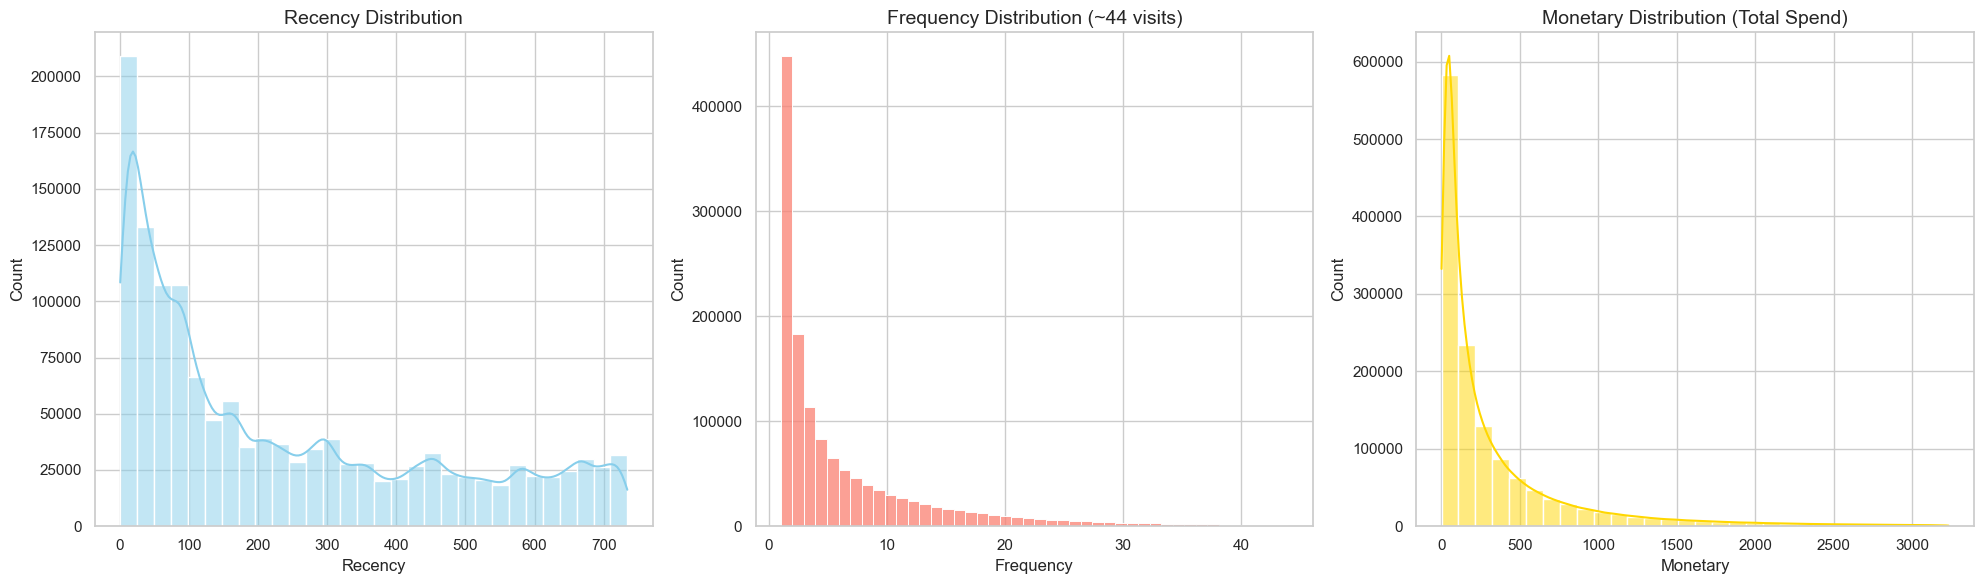

In [ ]:
# 시각화 (이제 rfm 변수를 사용하여 히스토그램을 그립니다)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Recency
sns.histplot(rfm['Recency'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Recency Distribution', fontsize=14)

# Frequency (상위 1% 제외하고 시각화하여 분포 파악 용이하게 설정)
f_limit = rfm['Frequency'].quantile(0.99)
sns.histplot(rfm[rfm['Frequency'] <= f_limit]['Frequency'], bins=int(f_limit), kde=False, ax=axes[1], color='salmon')
axes[1].set_title(f'Frequency Distribution (~{int(f_limit)} visits)', fontsize=14)

# Monetary (상위 1% 제외)
m_limit = rfm['Monetary'].quantile(0.99)
sns.histplot(rfm[rfm['Monetary'] <= m_limit]['Monetary'], bins=30, kde=True, ax=axes[2], color='gold')
axes[2].set_title(f'Monetary Distribution (Total Spend)', fontsize=14)

plt.tight_layout()
plt.show()

## 5분위수로 세그먼트 나누기

In [ ]:
# 1. 각 지표별로 백분율 순위(Percentile Rank) 계산
# pct=True 옵션은 0(최하위) ~ 1(최상위) 사이의 값을 반환합니다.
rfm['R_pct'] = rfm['Recency'].rank(pct=True, ascending=False) # Recency는 작을수록 좋으므로 내림차순
rfm['F_pct'] = rfm['Frequency'].rank(pct=True, ascending=True)
rfm['M_pct'] = rfm['Monetary'].rank(pct=True, ascending=True)

# 2. 백분율을 기반으로 1~5점 부여
def get_score(pct):
    if pct >= 0.8: return 5
    elif pct >= 0.6: return 4
    elif pct >= 0.4: return 3
    elif pct >= 0.2: return 2
    else: return 1

rfm['R_Score'] = rfm['R_pct'].apply(get_score)
rfm['F_Score'] = rfm['F_pct'].apply(get_score)
rfm['M_Score'] = rfm['M_pct'].apply(get_score)

# 3. 통합 점수 계산 (백분율 자체를 합산하여 평균을 낼 수도 있습니다)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

# 4. 세그먼트 분류 (백분율 기준 강화)
def get_segment_by_pct(row):
    # 상위 10% (R, F, M 백분율 평균이 0.9 이상인 진짜 VIP)
    avg_pct = (row['R_pct'] + row['F_pct'] + row['M_pct']) / 3
    
    if avg_pct >= 0.9:
        return '최상위 VVIP'
    elif row['RFM_Score'] >= 12:
        return '우수 고객'
    elif row['R_pct'] <= 0.2 and row['F_pct'] >= 0.6:
        return '이탈 위기 단골'
    elif row['M_pct'] >= 0.8 and row['R_pct'] <= 0.3:
        return '휴면 큰손'
    else:
        return '일반 고객'

rfm['Segment'] = rfm.apply(get_segment_by_pct, axis=1)

print(rfm['Segment'].value_counts(normalize=True) * 100) # 비중 확인(%)

Segment
일반 고객       68.699019
우수 고객       24.273304
최상위 VVIP     5.956416
이탈 위기 단골     0.610396
휴면 큰손        0.460865
Name: proportion, dtype: float64


## K-means

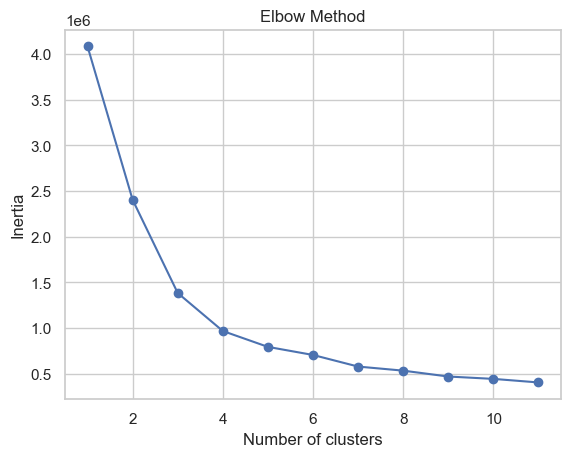

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. 분석에 사용할 컬럼 추출
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# 2. 데이터 스케일링 (단위를 일정하게 맞춤)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

#몇 개의 그룹으로 나누는 게 가장 좋을지 결정해야 합니다. 
# 보통 Elbow Method라는 그래프를 그려서 꺾이는 지점을 찾습니다.
import matplotlib.pyplot as plt

inertia = []
for k in range(1, 12):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 12), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [ ]:
# 통계적 신뢰도 (중심극한정리)
# # Silhouette Score(실루엣 계수)
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# 1. 무작위로 100,000개의 인덱스 추출 (130만 건 중 10만 건)
sample_size = 100000
np.random.seed(42) # 결과 재현을 위해 랜덤 시드 고정
indices = np.random.choice(len(rfm_scaled), sample_size, replace=False)

# 2. 추출된 인덱스에 해당하는 데이터만 따로 저장
rfm_scaled_sample = rfm_scaled[indices]

# 3. K=3일 때의 점수 계산
kmeans3 = KMeans(n_clusters=3, init='k-means++', random_state=42)
labels3 = kmeans3.fit_predict(rfm_scaled) # 전체 데이터 학습
labels3_sample = labels3[indices] # 샘플에 해당하는 라벨만 추출
score3 = silhouette_score(rfm_scaled_sample, labels3_sample)

# 4. K=4일 때의 점수 계산
kmeans4 = KMeans(n_clusters=4, init='k-means++', random_state=42)
labels4 = kmeans4.fit_predict(rfm_scaled) # 전체 데이터 학습
labels4_sample = labels4[indices] # 샘플에 해당하는 라벨만 추출
score4 = silhouette_score(rfm_scaled_sample, labels4_sample)

print(f"표본(10만건) 기준 K=3 실루엣 점수: {score3:.4f}")
print(f"표본(10만건) 기준 K=4 실루엣 점수: {score4:.4f}")

표본(1만건) 기준 K=3 실루엣 점수: 0.5022
표본(1만건) 기준 K=4 실루엣 점수: 0.5043


In [ ]:
# 1. 최적의 k=4로 모델 확정
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# 2. 각 클러스터별 평균값 계산 (원본 데이터 기준)
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).rename(columns={'Recency': '최근성(일)', 'Frequency': '구매횟수(번)', 'Monetary': '총구매금액($)'})

# 3. 클러스터별 고객 수 확인
cluster_profile['고객수'] = rfm['Cluster'].value_counts()

print(cluster_profile.sort_values('총구매금액($)', ascending=False))

             최근성(일)    구매횟수(번)     총구매금액($)     고객수
Cluster                                            
3         29.652834  42.032065  3189.160889   35303
1         56.792164  18.131518  1019.053345  210709
0        127.564804   4.141481   200.952103  708223
2        536.825626   1.791610    97.952927  406684


In [ ]:
# 2번(VIP) : 최근에도 왔고, 가장 자주, 많이 구매함. ZEP 라운지 우선 초대 및 한정판 드롭 타겟.
# 0번(잠재적 이탈 단골) :  꽤 자주 이용했었으나 최근 6개월간 방문 뜸함. 리워드 쿠폰으로 재방문 유도가 시급함.
# 3번 (신규 및 유망자) : 구매액은 적지만 최근 활동성이 좋음. 첫 구매 혜택이나 카테고리 확장 유도 필요.
# 1번 (휴먼 고객) :  1년 넘게 방문 안 함. 인원수가 가장 많음. 대규모 리타겟팅 광고나 수신동의 혜택 제안.

## Clouster3 타겟

In [ ]:
# 1. Cluster 3 고객 아이디만 추출
c3_users = rfm[rfm['Cluster'] == 3]['customer_id']

# 2. 이들이 구매한 상품 정보 결합 (df는 원본 거래 데이터)
c3_data = df[df['customer_id'].isin(c3_users)]

# 3. 이들이 가장 많이 산 '카테고리'와 '상품명' Top 10
print("🛍️ Cluster 3가 가장 선호하는 카테고리 Top 10")
print(c3_data['garment_group_name'].value_counts().head(10))

print("\n👕 Cluster 3가 가장 많이 산 구체적 상품명 Top 10")
print(c3_data['prod_name'].value_counts().head(10))

# 4. 이들의 평균 연령대 확인
avg_age = c3_data['age'].mean()
print(f"\n👥 Cluster 3의 평균 나이: {avg_age:.1f}세")

🛍️ Cluster 3가 가장 선호하는 카테고리 Top 10
garment_group_name
Jersey Fancy         981170
Trousers             599078
Jersey Basic         553266
Blouses              544967
Dresses Ladies       494179
Knitwear             493070
Under-, Nightwear    490194
Swimwear             405462
Accessories          291905
Trousers Denim       265386
Name: count, dtype: int64

👕 Cluster 3가 가장 많이 산 구체적 상품명 Top 10
prod_name
Jade HW Skinny Denim TRS     24432
Luna skinny RW               23366
Timeless Midrise Brief       15599
Tilly (1)                    13752
Despacito                    12204
Pluto RW slacks (1)          11984
Shake it in Balconette       11940
Perrie Slim Mom Denim TRS    10507
Cat Tee.                     10414
Madison skinny HW (1)        10227
Name: count, dtype: int64

👥 Cluster 3의 평균 나이: 37.3세


In [ ]:
# 1. 만약 고객 ID가 들어있는 데이터프레임 이름이 'user_df'나 'customers'라면 그걸 넣으세요.
# 만약 기억이 안 난다면, 클러스터링 직전에 사용했던 변수를 확인해보세요.

customer_clusters = pd.DataFrame({
    'customer_id': df['customer_id'].unique(), # 원본 df에서 중복 없는 고객 ID만 가져오기
    'cluster': kmeans.labels_
})

# 2. 이제 다시 합치기(Merge)
df_final = df.merge(customer_clusters, on='customer_id', how='inner')

# 3. Cluster 3만 필터링
c3_df = df_final[df_final['cluster'] == 3]

print(f"성공! Cluster 3 데이터 {len(c3_df)}건 추출 완료.")

성공! Cluster 3 데이터 807227건 추출 완료.


In [ ]:
df_final.head()

,t_dat,customer_id,article_id,price,sales_channel_id,FN,Active,club_member_status,fashion_news_frequency,age,...,graphical_appearance_name,colour_group_name,perceived_colour_value_name,perceived_colour_master_name,department_name,index_name,index_group_name,section_name,garment_group_name,cluster
0,2018-09-20,2,663713001,29.99,2,0,0,ACTIVE,NONE,24,...,Solid,Black,Dark,Black,Expressive Lingerie,Lingeries/Tights,Ladieswear,Womens Lingerie,"Under-, Nightwear",0
1,2018-09-20,2,541518023,17.99,2,0,0,ACTIVE,NONE,24,...,Solid,Light Pink,Dusty Light,Pink,Casual Lingerie,Lingeries/Tights,Ladieswear,Womens Lingerie,"Under-, Nightwear",0
2,2018-09-20,7,505221004,8.99,2,1,1,ACTIVE,Regularly,32,...,Melange,Pink,Medium Dusty,Pink,Tops Knitwear DS,Divided,Divided,Divided Selected,Knitwear,1
3,2018-09-20,7,685687003,9.99,2,1,1,ACTIVE,Regularly,32,...,Melange,Pink,Medium,Pink,Campaigns,Ladieswear,Ladieswear,Womens Everyday Collection,Special Offers,1
4,2018-09-20,7,685687004,9.99,2,1,1,ACTIVE,Regularly,32,...,Melange,Dark Green,Dark,Green,Campaigns,Ladieswear,Ladieswear,Womens Everyday Collection,Special Offers,1


In [ ]:
# df_final.reset_index(drop=True, inplace=True)
# df_final.to_csv('df_final_data.csv', index=False)

## 연관분석

In [ ]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# 1. 분석할 Cluster 3의 Top 10 카테고리 리스트 정의
target_categories = [
    'Jersey Fancy', 'Jersey Basic', 'Under-, Nightwear', 'Swimwear',
    'Trousers', 'Blouses', 'Knitwear', 'Dresses Ladies', 
    'Accessories', 'Trousers Denim'
]

# 2. 데이터 필터링 (에러 방지를 위해 df_final 사용)
# 'cluster' 컬럼이 있는 df_final에서 3번 클러스터만 먼저 추출합니다.
c3_df = df_final[df_final['cluster'] == 3]

# 그 중 우리가 정한 10개 카테고리에 속하는 데이터만 남깁니다.
c3_cat_only = c3_df[c3_df['garment_group_name'].isin(target_categories)].copy()

# 3. 장바구니 만들기 (pivot_table 방식이 더 안정적일 수 있습니다)
# 고객별+날짜별로 어떤 카테고리를 샀는지 10개의 열로 펼칩니다.
basket_cat = (c3_cat_only.groupby(['customer_id', 't_dat', 'garment_group_name'])['garment_group_name']
              .count().unstack().fillna(0))

# 4. 데이터 이진화 (구매 여부 0/1)
# 1개 이상 샀으면 1, 아니면 0으로 변환하여 연관분석 규격에 맞춥니다.
basket_sets_cat = basket_cat.map(lambda x: 1 if x > 0 else 0)

# 5. 연관분석 실행
# 카테고리 데이터는 조합이 흔하므로 min_support를 0.01(1%)로 설정합니다.
frequent_itemsets = apriori(basket_sets_cat, min_support=0.01, use_colnames=True)

# 6. 연관 규칙 생성 및 결과 확인
if not frequent_itemsets.empty:
    rules_cat = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
    final_rules_cat = rules_cat.sort_values('lift', ascending=False)
    
    print("--- Cluster 3: Top 10 카테고리 간 연관성 분석 결과 ---")
    print(final_rules_cat[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20))
else:
    print("조건을 만족하는 연관 규칙이 없습니다. min_support 값을 낮춰보세요.")

--- Cluster 3: Top 10 카테고리 간 연관성 분석 결과 ---
                                   antecedents  \
32       frozenset({Trousers, Dresses Ladies})   
33                        frozenset({Blouses})   
28                        frozenset({Blouses})   
25   frozenset({Jersey Fancy, Dresses Ladies})   
55         frozenset({Jersey Fancy, Trousers})   
58                        frozenset({Blouses})   
127  frozenset({Jersey Fancy, Trousers Denim})   
130                      frozenset({Trousers})   
100                  frozenset({Jersey Basic})   
97   frozenset({Jersey Fancy, Trousers Denim})   
29                 frozenset({Dresses Ladies})   
24          frozenset({Jersey Fancy, Blouses})   
131                frozenset({Trousers Denim})   
126        frozenset({Jersey Fancy, Trousers})   
71                       frozenset({Trousers})   
66              frozenset({Blouses, Knitwear})   
38          frozenset({Blouses, Jersey Basic})   
39                   frozenset({Jersey Fancy})   
98   fr

In [ ]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# 1. 분석할 Cluster 3의 Top 10 상품 리스트
target_products = [
    'Jade HW Skinny Denim TRS', 'Timeless Midrise Brief', 'Luna skinny RW',
    'Tilly (1)', 'Simple as That Triangle Top', 'Cat Tee.', 
    'Tilda tank', 'Simple as that Cheeky Tanga', 'Shake it in Balconette', 
    'Skinny Ankle R.W Brooklyn'
]

# 2. 데이터 필터링 (df_final 사용 확인)
c3_df = df_final[df_final['cluster'] == 3]
c3_prod_only = c3_df[c3_df['prod_name'].isin(target_products)].copy()

# 3. 장바구니 만들기
# .reset_index()와 .set_index() 과정을 줄여서 더 직관적으로 변경했습니다.
basket_prod = (c3_prod_only.groupby(['customer_id', 't_dat', 'prod_name'])['prod_name']
               .count().unstack().fillna(0))

# 4. 데이터 이진화 (0/1 변환)
basket_sets_prod = basket_prod.map(lambda x: 1 if x > 0 else 0)

# 5. 연관분석 실행
# 결과가 하나도 안 나올 경우를 대비해 에러 방지 코드를 추가했습니다.
frequent_itemsets = apriori(basket_sets_prod, min_support=0.001, use_colnames=True)

if not frequent_itemsets.empty:
    # 6. 연관 규칙 생성
    rules_prod = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
    
    # 7. 결과 확인 (가독성을 위해 frozenset을 문자열로 변환하여 출력)
    final_rules_prod = rules_prod.sort_values('lift', ascending=False).copy()
    final_rules_prod['antecedents'] = final_rules_prod['antecedents'].apply(lambda x: ', '.join(list(x)))
    final_rules_prod['consequents'] = final_rules_prod['consequents'].apply(lambda x: ', '.join(list(x)))
    
    print("--- Cluster 3: 인기 상품 Top 10 간 연관성 분석 ---")
    print(final_rules_prod[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20))
else:
    print("연관 규칙을 찾지 못했습니다. min_support 값을 더 낮춰보세요.")

--- Cluster 3: 인기 상품 Top 10 간 연관성 분석 ---
                                          antecedents  \
32  Timeless Midrise Brief, Simple as that Cheeky ...   
31  Simple as That Triangle Top, Shake it in Balco...   
27  Timeless Midrise Brief, Simple as That Triangl...   
36                        Simple as that Cheeky Tanga   
13                        Simple as that Cheeky Tanga   
10  Simple as That Triangle Top, Shake it in Balco...   
22  Timeless Midrise Brief, Simple as that Cheeky ...   
23                        Simple as That Triangle Top   
5                         Simple as that Cheeky Tanga   
4                         Simple as That Triangle Top   
33  Simple as that Cheeky Tanga, Shake it in Balco...   
30  Timeless Midrise Brief, Simple as That Triangl...   
29  Timeless Midrise Brief, Simple as that Cheeky ...   
34                        Simple as That Triangle Top   
28  Simple as that Cheeky Tanga, Simple as That Tr...   
35                             Timeless Midrise

## LTV

--- Cluster 3 LTV 핵심 지표 ---
평균 총 구매액(M): 374.1566
평균 활동 기간: 273.8일
평균 구매 빈도(F): 22.9회
일일 기대 가치: 20.136705


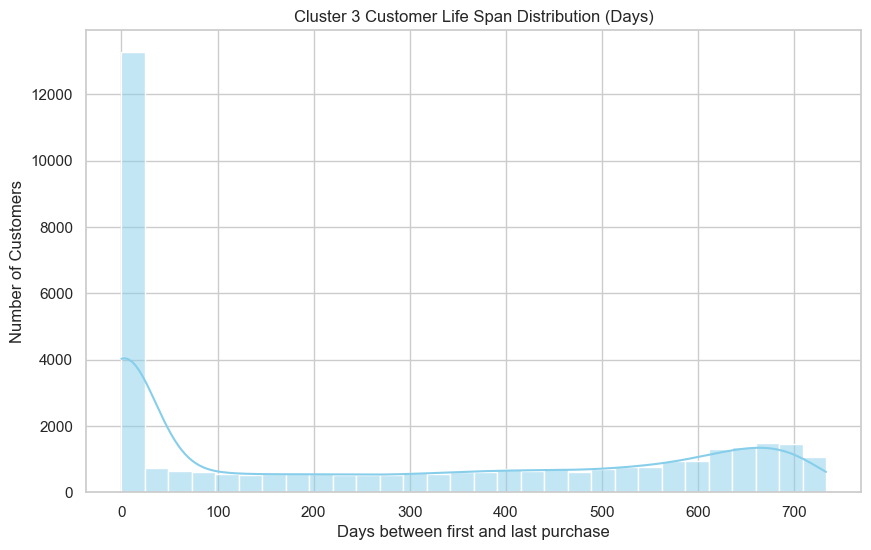

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cluster 3 데이터만 추출 (날짜 데이터를 날짜형식으로 변환)
c3_df = df_final[df_final['cluster'] == 3].copy()
c3_df['t_dat'] = pd.to_datetime(c3_df['t_dat'])

# 2. 고객별 LTV 관련 지표 계산
# 고객별로 [첫 구매일, 마지막 구매일, 총 구매금액, 총 구매횟수]를 구합니다.
ltv_base = c3_df.groupby('customer_id').agg({
    't_dat': ['min', 'max', 'count'],
    'price': 'sum'
}).reset_index()

# 컬럼 이름 정리
ltv_base.columns = ['customer_id', 'first_purchase', 'last_purchase', 'frequency', 'total_monetary']

# 3. 고객별 활동 기간(Life Span) 계산 (단위: 일)
ltv_base['life_span_days'] = (ltv_base['last_purchase'] - ltv_base['first_purchase']).dt.days

# 4. 활동 기간이 0일인 고객(단발성 구매)을 위해 최소 1일로 보정 후 일일 평균 매출 계산
ltv_base['daily_value'] = ltv_base['total_monetary'] / (ltv_base['life_span_days'] + 1)

# 5. Cluster 3 전체의 평균 지표 출력
print(f"--- Cluster 3 LTV 핵심 지표 ---")
print(f"평균 총 구매액(M): {ltv_base['total_monetary'].mean():.4f}")
print(f"평균 활동 기간: {ltv_base['life_span_days'].mean():.1f}일")
print(f"평균 구매 빈도(F): {ltv_base['frequency'].mean():.1f}회")
print(f"일일 기대 가치: {ltv_base['daily_value'].mean():.6f}")

# 6. 시각화 (활동 기간 분포)
plt.figure(figsize=(10, 6))
sns.histplot(ltv_base['life_span_days'], bins=30, kde=True, color='skyblue')
plt.title('Cluster 3 Customer Life Span Distribution (Days)')
plt.xlabel('Days between first and last purchase')
plt.ylabel('Number of Customers')
plt.show()

## 회귀 분석

--- [클러스터 3] 이탈 예측 모델 성적표 ---
              precision    recall  f1-score   support

       False       0.69      0.75      0.72        75
        True       0.84      0.80      0.82       123

    accuracy                           0.78       198
   macro avg       0.76      0.77      0.77       198
weighted avg       0.78      0.78      0.78       198

ROC-AUC Score: 0.8391


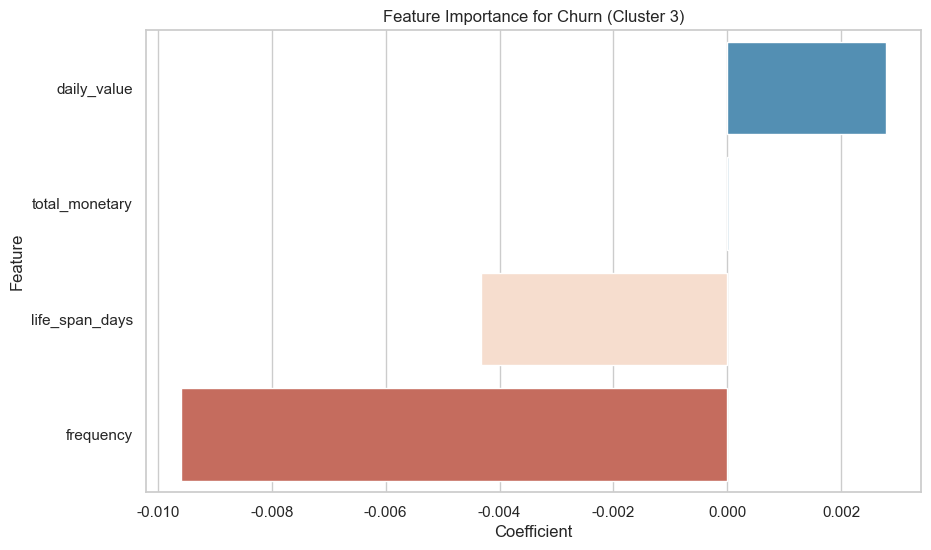

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 준비 (클러스터 3 타겟팅)
# ltv_base(고객별 요약 데이터)에 Cluster 정보가 포함되어 있어야 합니다.
target_df = ltv_base[ltv_base['Cluster'] == 3].copy()

# 2. 이탈 라벨(y) 생성: 최근 구매일로부터 90일 이상 지났으면 이탈(1)
max_date = target_df['last_purchase'].max()
target_df['is_churn'] = (max_date - target_df['last_purchase']).dt.days > 90

# 3. 특성 변수(X)와 타겟 변수(y) 설정
# 비즈니스 인사이트를 위해 수치형 변수 4개를 사용합니다.
features = ['frequency', 'total_monetary', 'life_span_days', 'daily_value']
X = target_df[features]
y = target_df['is_churn']

# 4. 데이터 분할 (학습 8: 테스트 2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. 모델 학습 (로지스틱 회귀)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 6. 예측 및 성능 평가
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("--- [클러스터 3] 이탈 예측 모델 성적표 ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# 7. 변수 중요도 (회귀 계수) 시각화
# 어떤 요인이 이탈에 가장 큰 영향을 주는지 확인합니다.
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_[0]})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='RdBu_r')
plt.title('Feature Importance for Churn (Cluster 3)')
plt.show()

In [ ]:
# frequency (가장 긴 빨간 막대): 구매 빈도
# 뜻: 고객이 우리 가게를 얼마나 자주 방문했는지를 나타냄
# 해석: "자주 올수록 절대 안 떠난다"는 뜻. 반대로 말하면 클러스터 3이 떠나는 가장 큰 이유는 방문 횟수가 뜸해지기 때문.

# life_span_days (살구색 막대): 가입 기간
# 뜻: 처음 구매한 날부터 마지막 구매한 날까지의 기간입니다.
# 해석: 우리 브랜드와 오래 알고 지낸 사이일수록 잘 안 떠난다는 것을 의미

# daily_value (오른쪽 파란 막대): 일평균 지출 가치
# 뜻: 전체 구매 금액을 가입 기간으로 나눈 값으로, 하루 평균 얼마꼴로 썼는지를 보여줌.
# 해석: 특이하게 오른쪽으로 뻗어 있음. 이는 클러스터 3 중에서 "한 번 올 때 왕창 사고 오랫동안 안 오는 손님"들이 오히려 이탈할 위험이 더 높다는 신호.

# total_monetary (거의 없는 막대): 총 구매 금액
# 뜻: 지금까지 쓴 돈의 총합
# 해석: 막대가 거의 보이지 않음. 클러스터 3에게는 "지금까지 얼마를 썼느냐"는 이탈 여부를 결정하는 데 있어 별로 중요하지 않은 정보라는 뜻.